In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def create_data():
        # Generate random data for miles driven (in thousands) and age of the car (in years)
        np.random.seed(42)  # For reproducibility
        miles_driven = np.random.randint(5, 200, size=100)  # Miles driven between 5k and 200k
        car_age = np.random.randint(1, 20, size=100)  # Car age between 1 and 20 years
        
        # Combine features into a single dataset
        x = np.column_stack((miles_driven, car_age))
        # print(x)
        
        # Generate price with some noise
        # Price decreases with higher mileage and older cars
        price = 30000 - (miles_driven * 30) - (car_age * 500) + np.random.randint(-2000, 2000, size=100)
        
        # plot_out_init_data(miles_driven, car_age, price)
        
        return x, price

In [4]:
X, Y = create_data()

print(X[:, 0])
print(X[:, 1])
print(Y)

[107 184  97  19 111  76 193  25 107 126  79  92 121 104 108 156 135 154
  57   6  92 162  42 134 196 192  25 165  62  26  93  53  63 174 192  19
 194 194 179 194  55 112  59  68 135  55 139  25  77 171  22 136  93  64
  18  13  94  57 134  88  96 115 192 176  12 179  39  85 168  54 108 136
   6 138  58 110   8  58 195 150  48 166 194  18  99  52  19 194  44  86
 115  57  28 158 192 128  45 161  19  49]
[ 1  7  9  1 12  8 11 19 17  8  3  3  1  5 10  7  9  7  9  8 12  2  1 16
  5  3 12  8  3  1  3  5 15 14  3  1  5 14  7  9 15 15 10 13 19  7 17  4
  5  7 13 15 11  4 13  7 19  2 10 13  6 12 12 11  7  1  1 13  9  3  7  6
  8  9  5  1 19 10 12 15  9 17 17 12  7  2  3 17  5 17 17 17  2  2  5  1
  1 19  2 12]
[27067 20675 22323 28369 20964 22555 20220 17952 19545 20342 24530 24506
 24163 24707 23668 22751 23131 20077 24819 25750 22822 24939 28431 16588
 22892 21887 21436 22447 27151 30140 25504 24569 21421 18782 22695 29380
 21049 17166 20664 17826 22069 20051 22964 21303 14938 25826 17289 2

In [5]:
def plot_out_init_data(X, price):
    plt.figure(figsize=(12, 5))
    
    miles_driven = X[:, 0]
    car_age = X[:, 1]
    

    plt.subplot(1, 3, 1)
    plt.scatter(miles_driven, price, color='blue', alpha=0.6)
    plt.title("Miles Driven vs. Price")
    plt.xlabel("Miles Driven (in thousands)")
    plt.ylabel("Price (in dollars)")
    plt.grid(True)

    # Plot Age of Car vs. Price
    plt.subplot(1, 3, 2)
    plt.scatter(car_age, price, color='green', alpha=0.6)
    plt.title("Age of Car vs. Price")
    plt.xlabel("Age of Car (in years)")
    plt.ylabel("Price (in dollars)")
    plt.grid(True)
    
    # plot miles driven vs. age
    plt.subplot(1, 3, 3)
    plt.scatter(car_age, miles_driven, color='red', alpha=0.6)
    plt.title("miles driven vs. car age")
    plt.xlabel("Car age")
    plt.ylabel("miles driven")
    plt.grid(True)

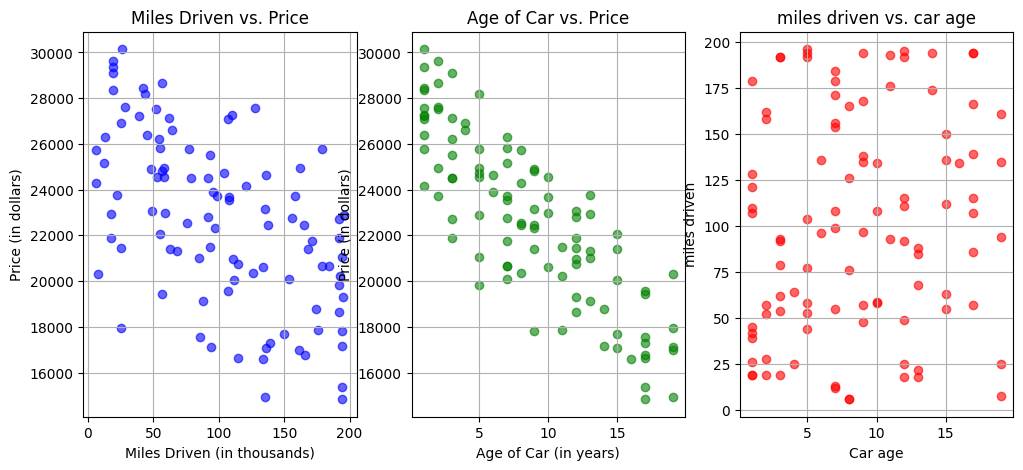

In [6]:
plot_out_init_data(X, Y)

In [7]:
def linear_eq(X, w, b):
    f_x = np.dot(X, w) + b
    return f_x
    

In [8]:
def cost_function(error, m):
    cost = (np.sum(error**2)) / (2*m)
    return cost

In [9]:
# testing with random parameters in my mind

w = [-5, 10]
b = 100
error = linear_eq(X, w, b) - Y
cost = cost_function(error, X.shape[0])
print(cost)

270406902.055


In [10]:
def convergence(cost, iterations):
    plt.figure(figsize=(8, 5))
    plt.plot(iterations, cost, marker="o", linestyle='dotted', color='orange')
    
    plt.xlabel('Iterations', fontsize=12) 
    plt.ylabel("J(w, b)", fontsize=12)
    # plt.yscale('log') # i might need it if the cost is too big tho. 
    plt.title('Cost function optimization')

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

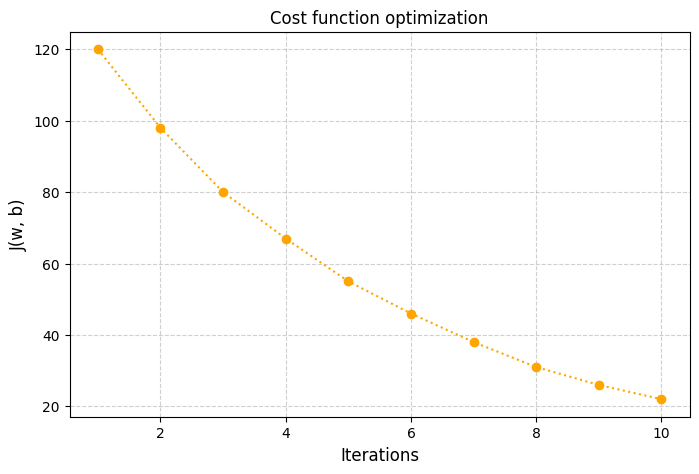

In [11]:
# NOTE: test run is going great
iterations = list(range(1, 11))  # 10 iterations
cost = [120, 98, 80, 67, 55, 46, 38, 31, 26, 22]  # sample cost values
convergence(cost, iterations)

In [12]:
def gradient_descent(alpha, count, w, b):
    m, feature = X.shape
    temp_w = np.zeros(feature)
    temp_b = 0
    cycle = 1/100 * count
    cost = 0
    cost_history = []
    iterations = []
    tolerance = 1e-3
    max_patience = 10
    patience = 0
    prev_cost = float('inf')
    
    for i in range(count):
        error = linear_eq(X, w, b) - Y
        cost = cost_function(error, m)
        
        if abs(prev_cost - cost) < tolerance:
            patience += 1
            if patience >= max_patience:
                print(f"Early stopping at iteration {i} — cost stopped improving.")
                break
        else:
            patience = 0  # reset patience if cost improved

        prev_cost = cost

        
        if (i+1) % cycle == 0:
            cost_history.append(cost)
            iterations.append((i+1))
            convergence(cost_history, iterations)
        for j in range(feature):
            # NOTE: i was updating w ... i should do it at the end
            # w[j] = w[j] - ( alpha * 1/m * np.sum(error * X[:, j]))
            temp_w[j] = 1/m * np.sum(error * X[:, j])
            
        temp_b = 1/m * np.sum(error)
        w = w - (alpha * temp_w)
        b = b - (alpha * temp_b)
    
    return w, b

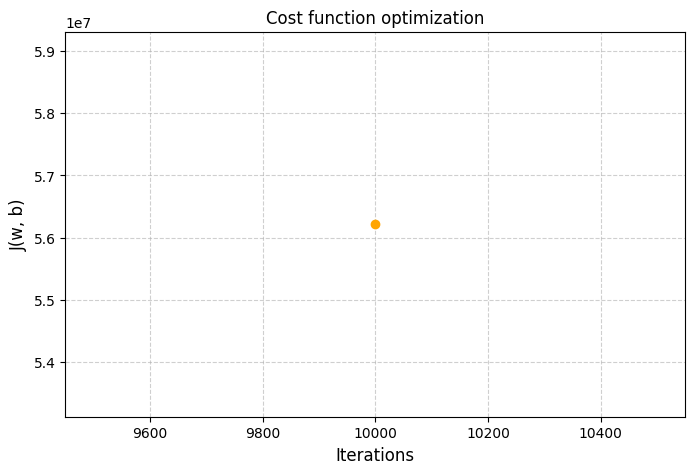

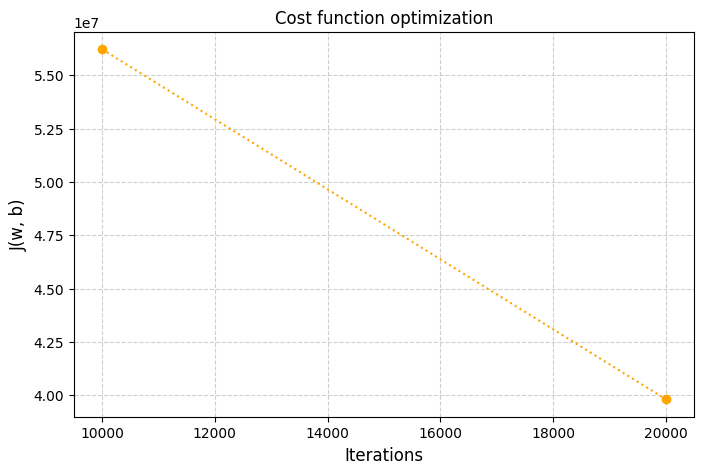

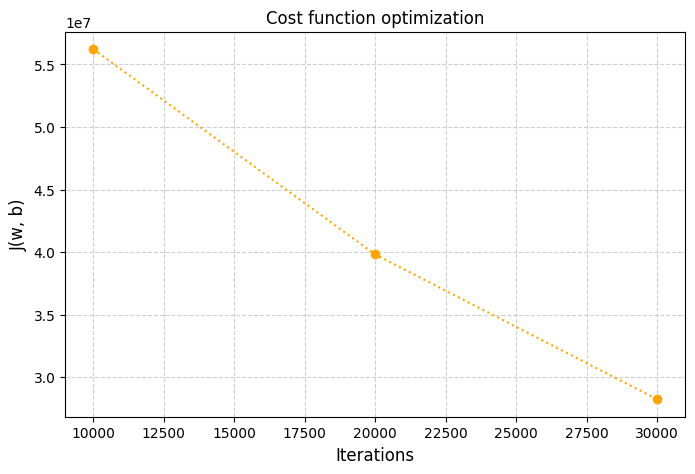

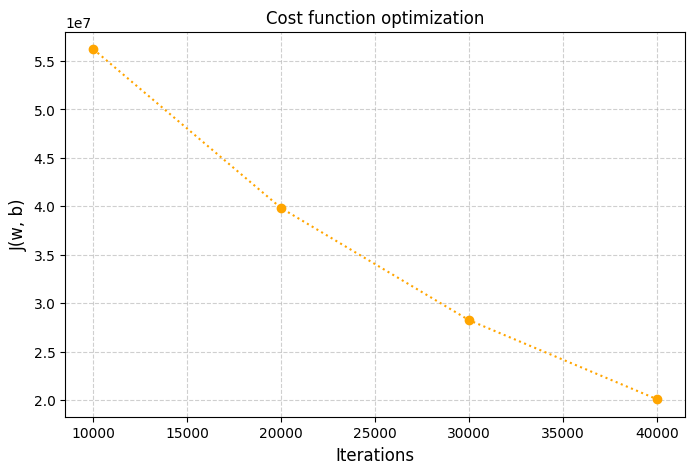

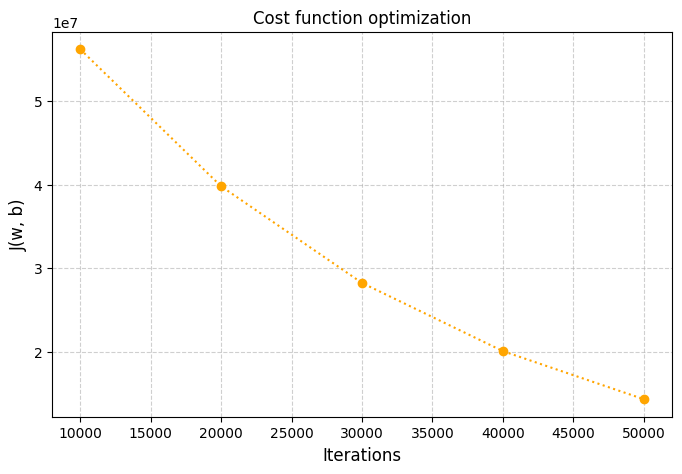

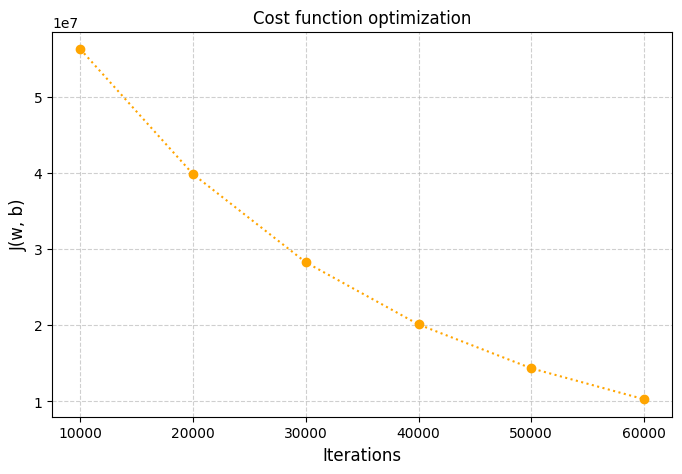

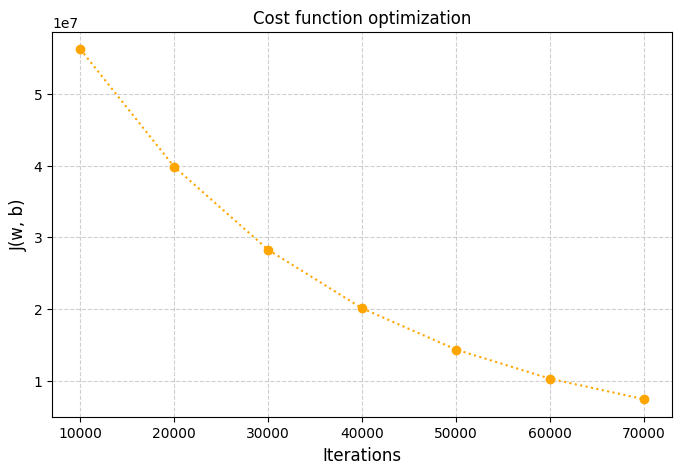

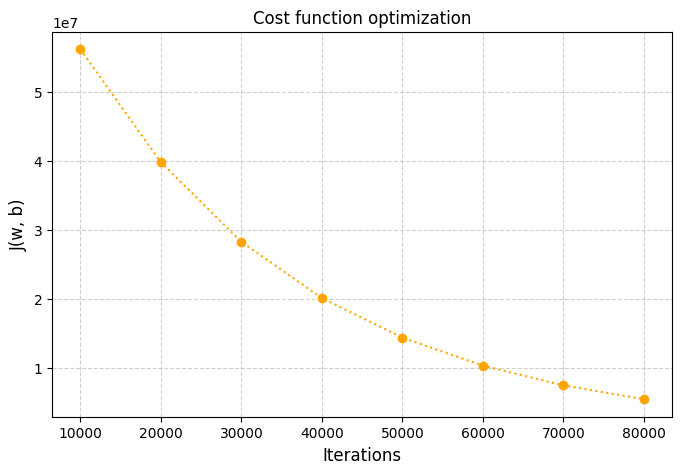

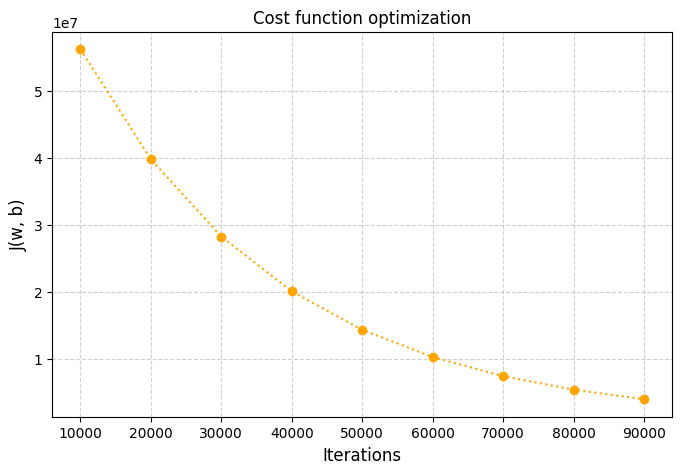

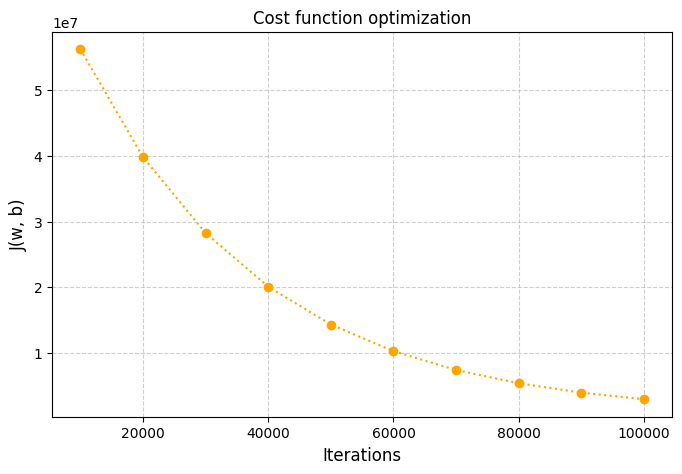

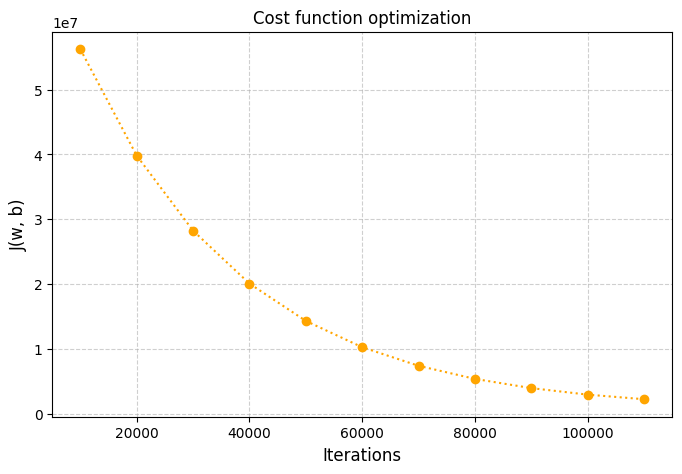

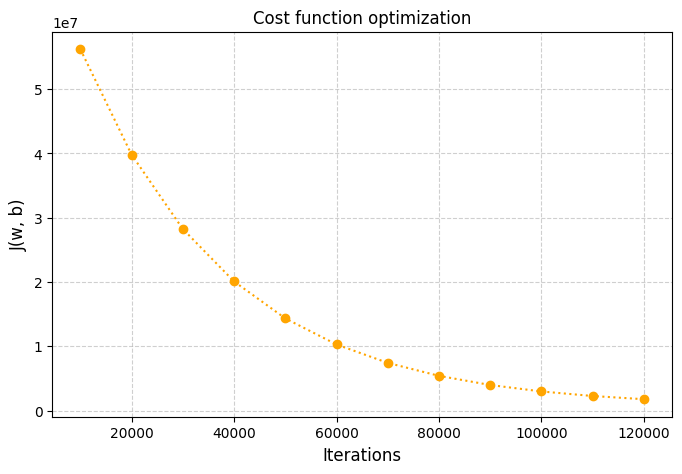

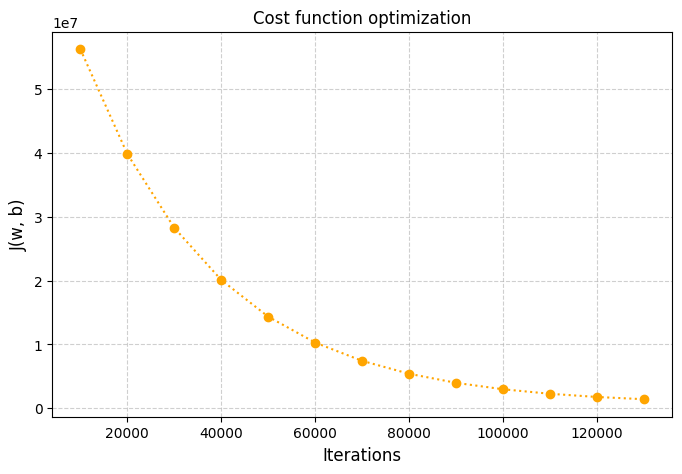

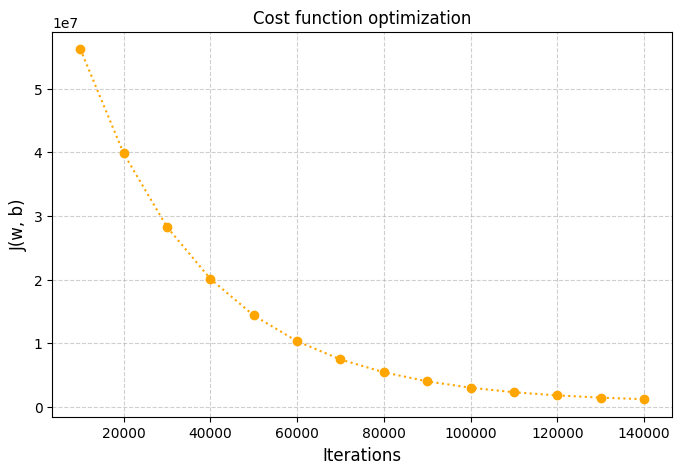

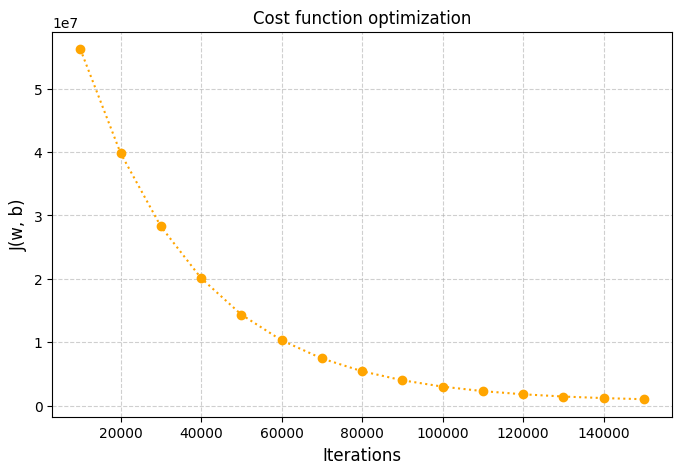

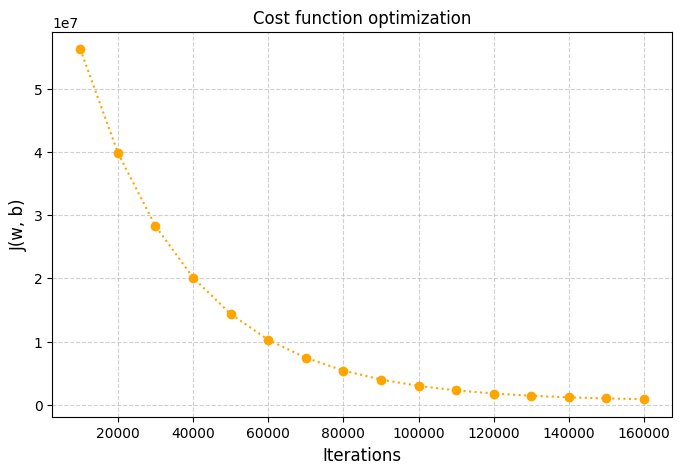

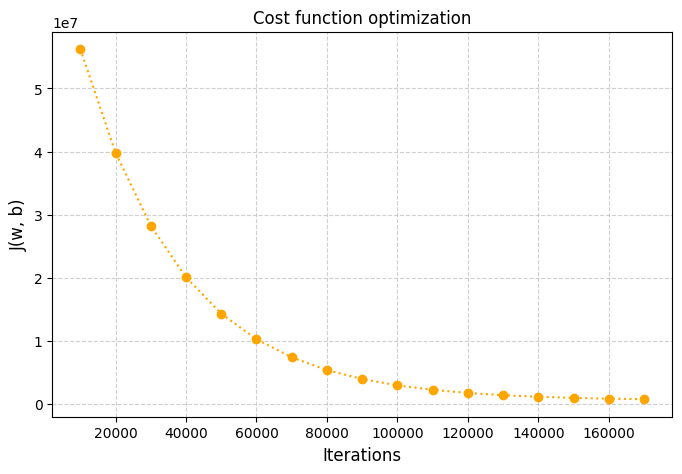

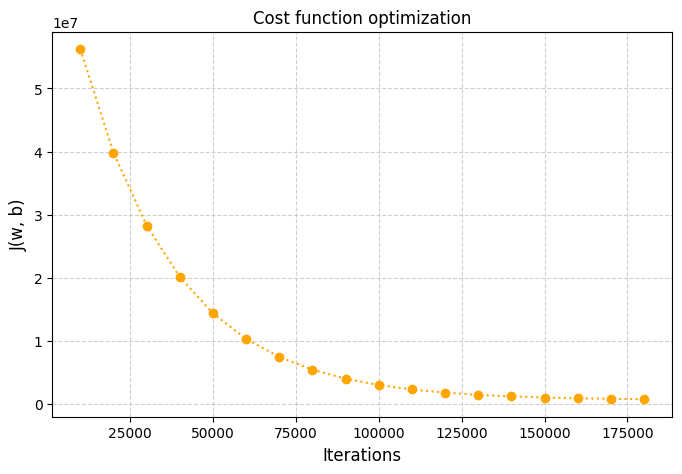

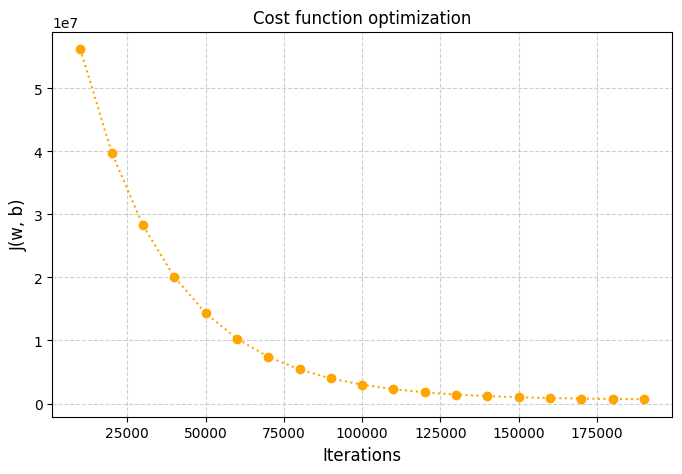

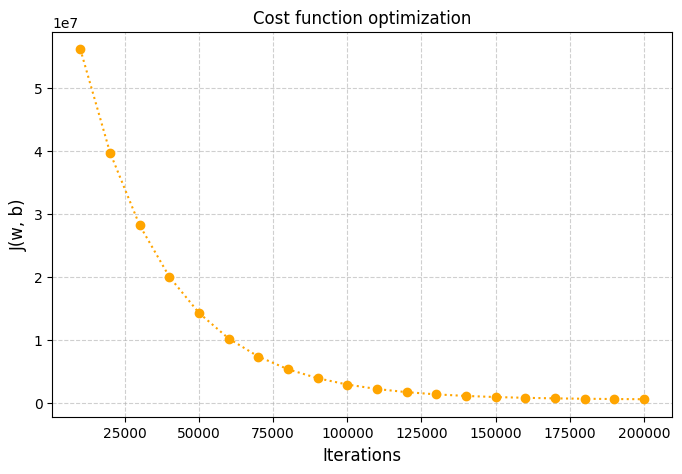

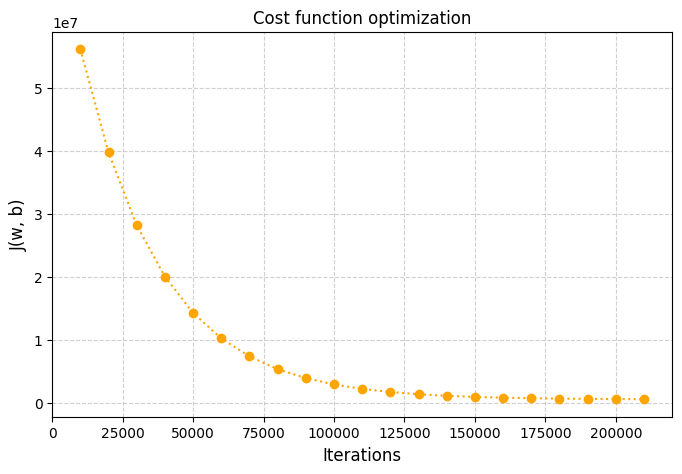

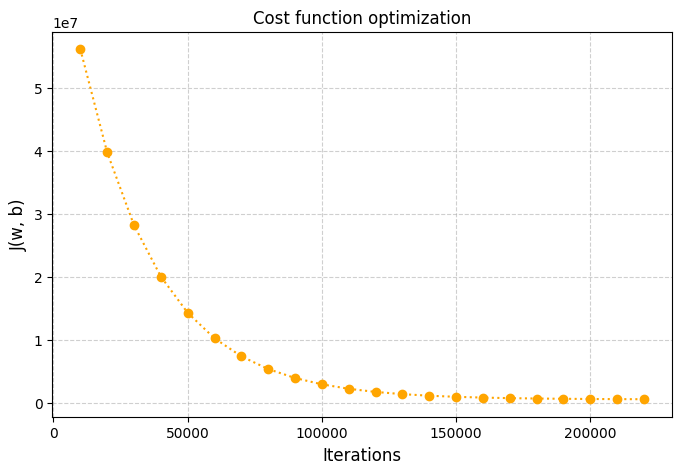

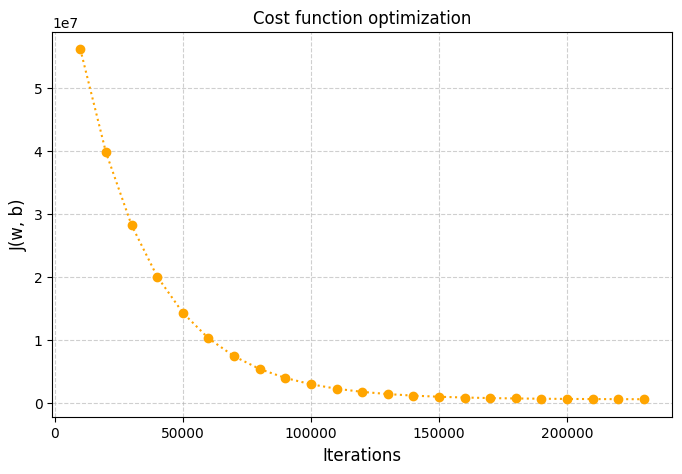

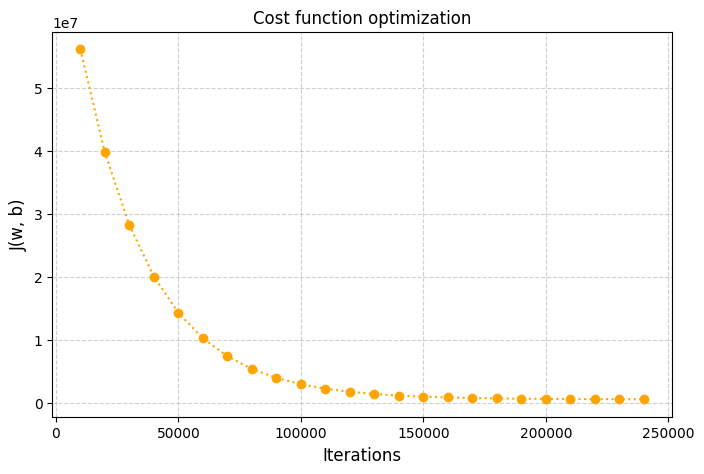

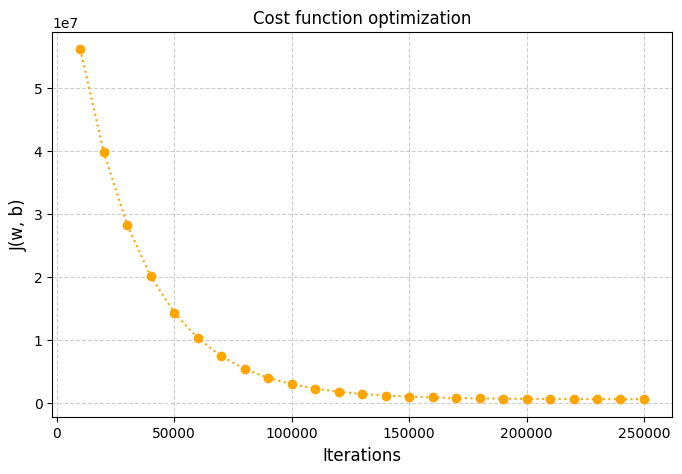

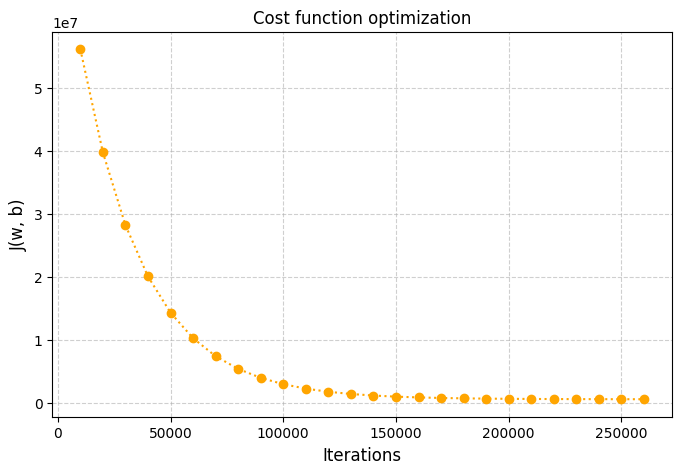

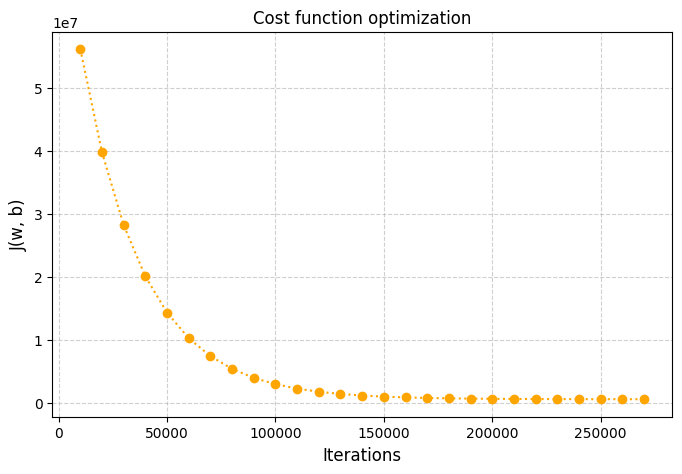

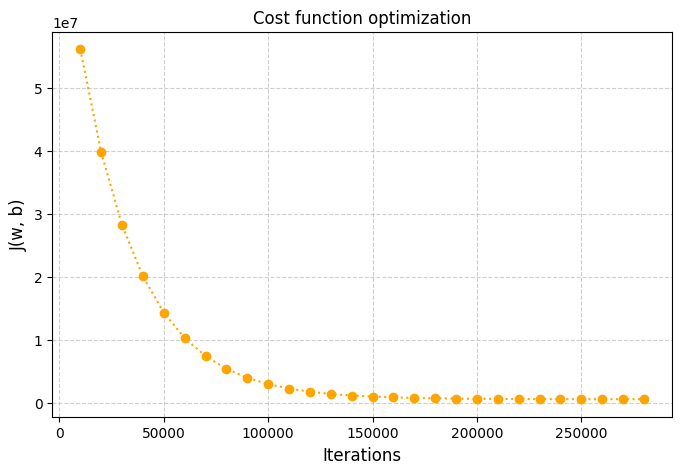

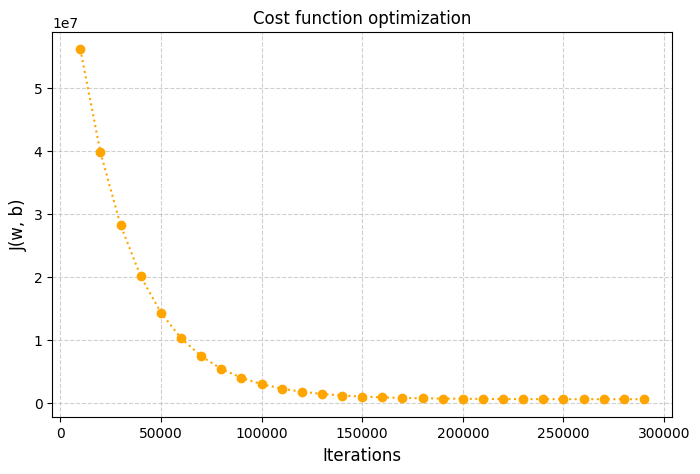

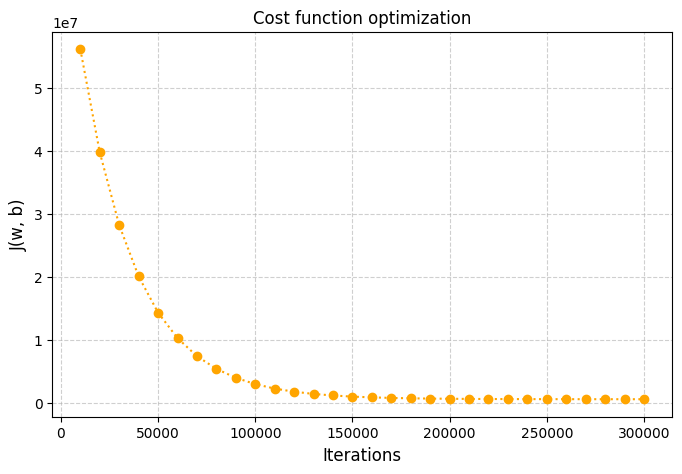

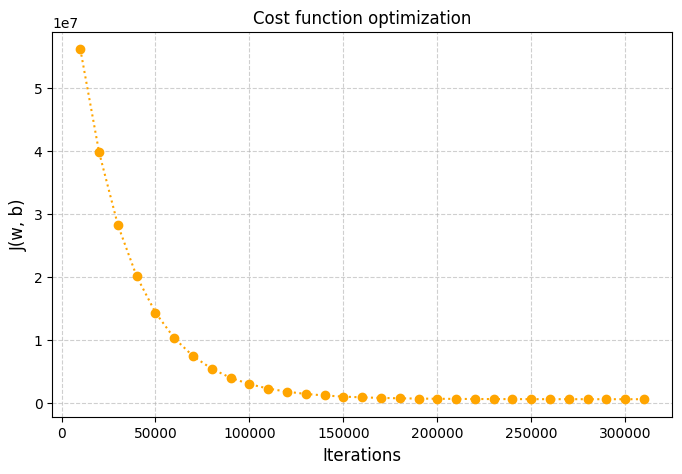

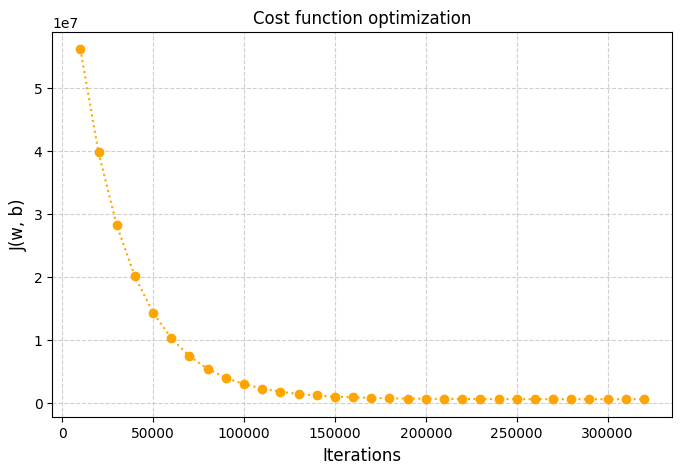

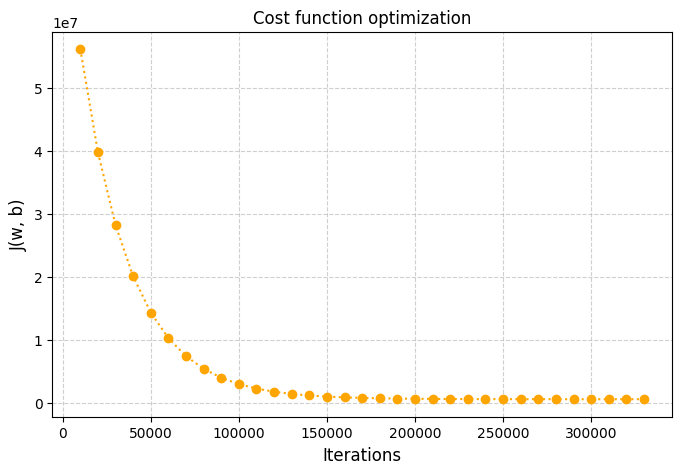

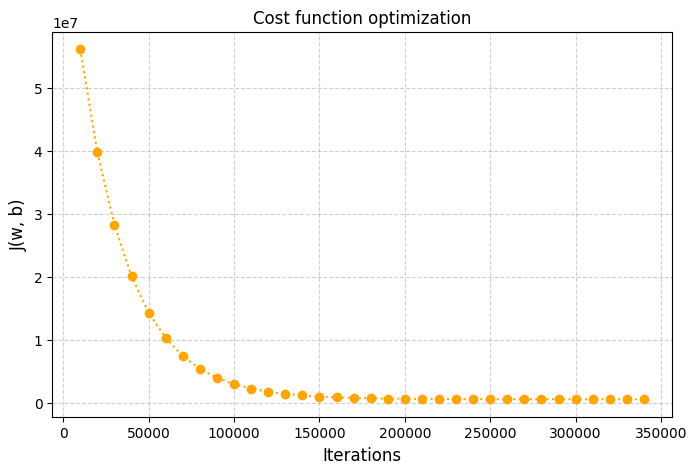

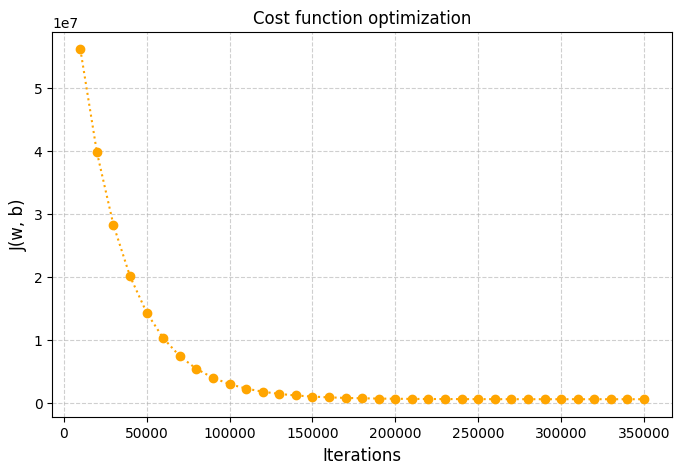

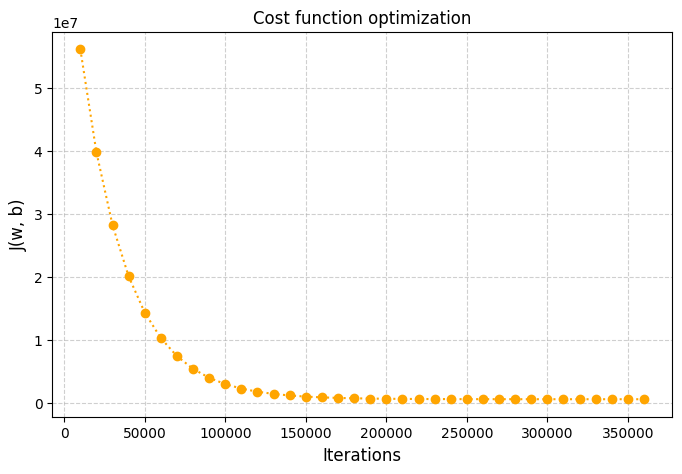

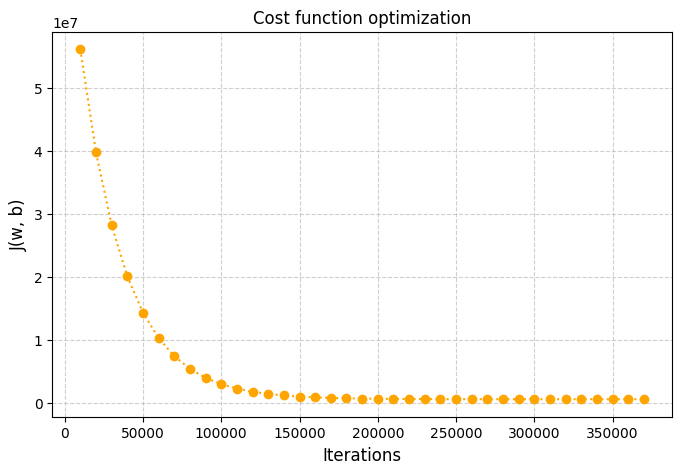

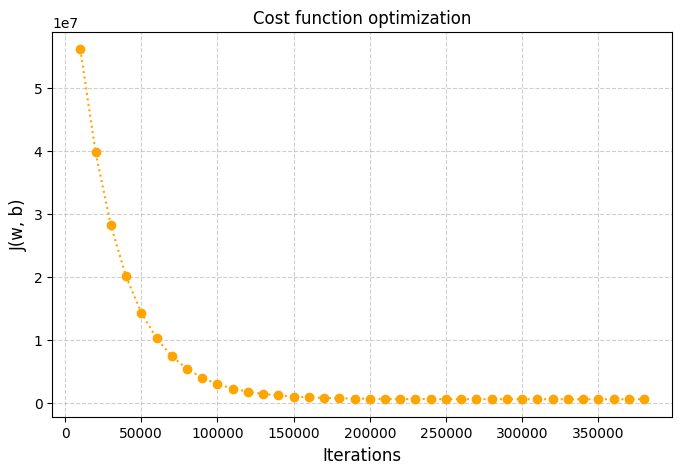

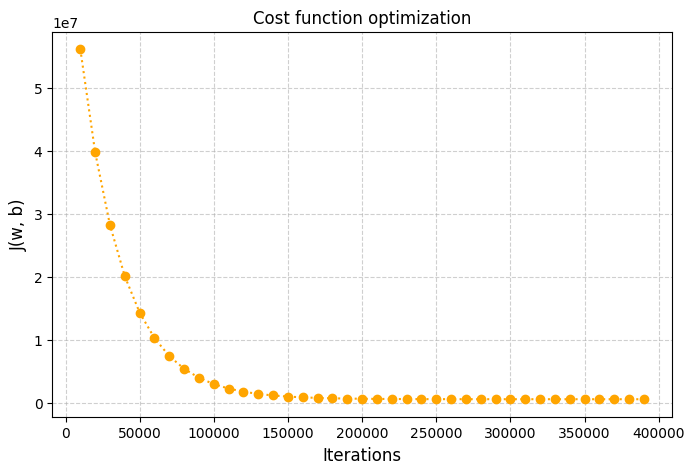

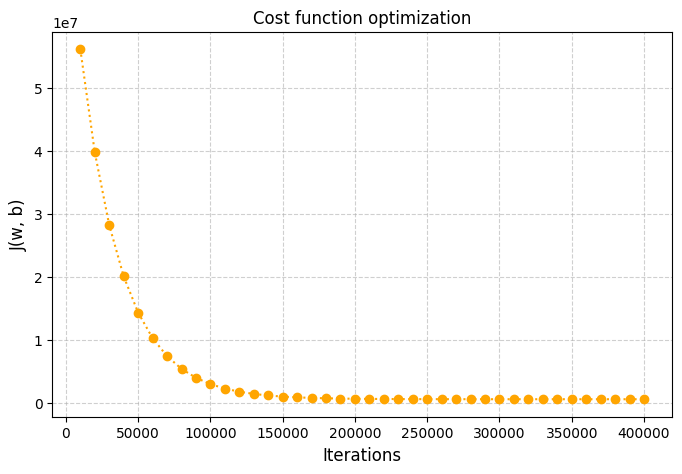

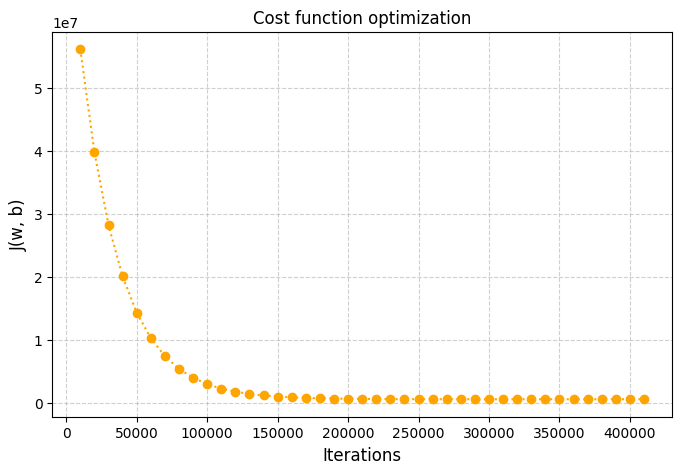

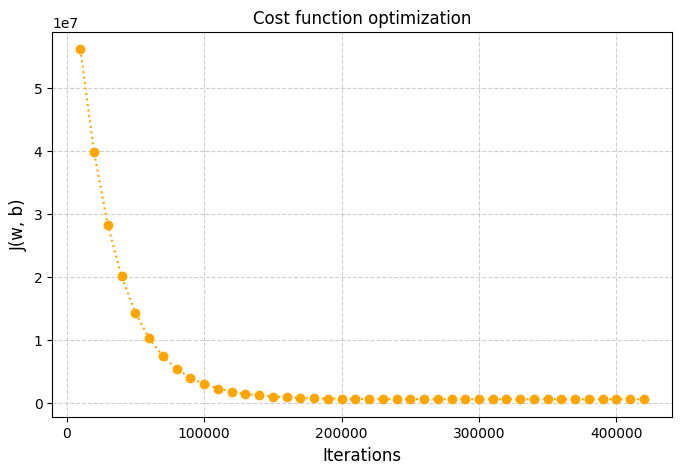

Early stopping at iteration 424694 — cost stopped improving.


In [13]:
w = np.random.randint(1, 5, size=X.shape[1])
b = 10
w_update, b_update = gradient_descent(0.0001, 1000000, w, b)

In [14]:
print(w_update)
print(b_update)

error = abs(linear_eq(X, w_update, b_update) - Y)
cost = cost_function(error, X.shape[0])
print(cost)

[ -28.73582175 -521.47172255]
30059.783139772284
578056.3135351721


In [32]:
# this is to show that my gradient descent from scartch is actually correct
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, Y)

print("Sklearn Coefficients:", model.coef_)
print("Sklearn Intercept:", model.intercept_)

Sklearn Coefficients: [ -28.81608841 -522.26391427]
Sklearn Intercept: 30077.87560950174


In [30]:
def final_graph():
    """

    to plot the final graph: we need X, Y, w_update, b_update
    
    as always, we are going to plot X and Y data points on graph 
    
    additional thing: we are going to need a line: w_update, X, b_update 
    
    """
    
    # Create grid from feature space
    # NOTE: the reason for that is to convert them into 2D for contour plot 
    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    X1, X2 = np.meshgrid(x1, x2)  # Now X1 and X2 are 2D
    
    
    Z = w_update[0] * X1 + w_update[1] * X2 + b_update  # Or use your own linear_eq function

    # Contour plot of the predicted values (regression surface)
    plt.figure(figsize=(10, 6))
    cp = plt.contourf(X1, X2, Z, levels=50, cmap='coolwarm')
    plt.colorbar(cp)

    # Optional: show lines (not just filled contours)
    plt.contour(X1, X2, Z, levels=20, colors='black', linewidths=0.5)

    # Overlay the actual data points, colored by their real price
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolor='k', cmap='coolwarm')

    plt.xlabel('miles driven')
    plt.ylabel('car age')
    plt.title('Contour Plot with Predicted Price Surface')
    plt.grid(True)
    plt.show()
    

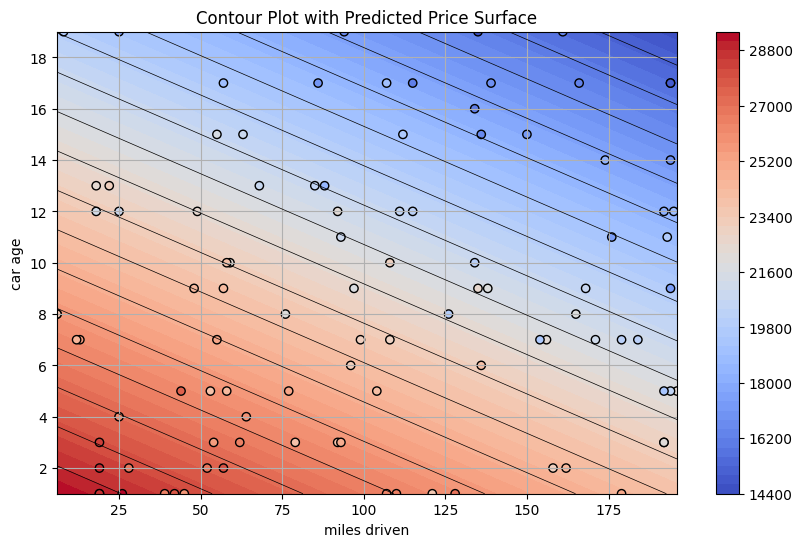

In [31]:
final_graph()
# ok this looks like overfitting a lot
# but on the other hand, we are not sure if this is we are not plotting the 3D 